In [1]:
import ODESolve_slow as ODE
from constants import mN
import numpy as np
import thermodynamics as thermo
from constants import me, mpl, zeta3
import weakrates as weak
import expansion as ex
import nseabundance as nse
import derivatives as der
import matplotlib.pyplot as plt

In [2]:
MeVtoT9 = 11604525006.1657/10**9

In [5]:
cmgstoMeV = 1.52e-16

In [7]:
def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN

In [9]:
def tpga(T):
    T9 = T*MeVtoT9
    F = T9**(-2/3)*2.2e4*np.exp(-3.869/(T9**(1/3)))*((T9**(1/3))*0.108+1.+(T9**(2/3))*1.68+T9*1.26+(T9**(4/3))*0.551+(T9**(5/3))*1.06)

    return F*cmgstoMeV*mN

In [11]:

# nB = eta*(3/2)*zeta3*T**3
# gammaf=(f[12]*nb)/mN

In [13]:
PNGD_INDEX = 0
TPGA_INDEX = 1

In [15]:
def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))

#creates array of 12 dependent variables
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN
    

def f(a,y,p):
    T, t, eta, A = sep(y)
    nB = eta*(3/2)*zeta3*T**3
    Gamma_f = np.zeros(2)
    Gamma_f[PNGD_INDEX] = pngd(T)*nB
    Gamma_f[TPGA_INDEX] = tpga(T)*nB
    A_NSE = nse.nse(T, eta, A[nse.P_INDEX], A[nse.N_INDEX])
    Gamma_r = np.zeros(len(Gamma_f))
    Gamma_r[PNGD_INDEX] = Gamma_f[PNGD_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
    Gamma_r[TPGA_INDEX] = Gamma_f[TPGA_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
  
    der=np.zeros(3)
    d=np.zeros(9)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(-1/2)
    der[2] = -3*eta*((1/T)*der[0]+(1/a))

    d[nse.P_INDEX] += A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.P_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.N_INDEX] -= A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.N_INDEX] += A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.N_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.N_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.H2_INDEX] += A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.H2_INDEX] -= A[nse.H2_INDEX]*Gammar
    d[nse.H3_INDEX] = 0
    d[nse.HE3_INDEX] = 0
    d[nse.HE4_INDEX] = 0
    d[nse.BE7_INDEX] = 0
    d[nse.LI7_INDEX] = 0
    d[nse.LI6_INDEX] = 0

    return depvar(der[0], der[1], der[2], d*der[1])

In [17]:
a0 = 0.1    
T0 = 10
t0 = 0
eta0 = (6.1e-10)*(11/4)
Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
Yn0 = 1-Yp0

y0 = depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
p=2
dx0=0.001

N_step = 1000
dN = 50

x_final = 100

a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

print(dx)


False
[1.00000000e-03 2.04754638e-05 2.22495304e-05 ... 2.23934690e-17
 2.62550455e-17 2.60746885e-17]


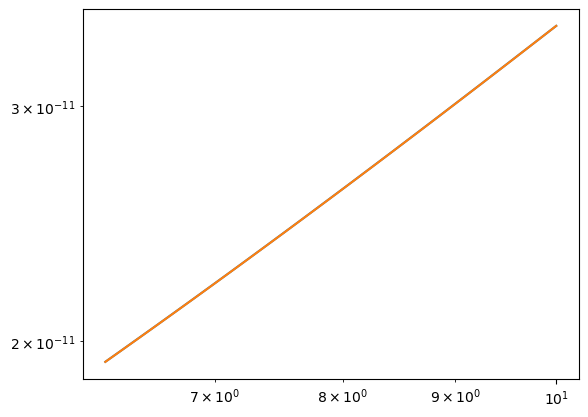

In [18]:
plt.figure()
Tcm=1/a
Y2H = np.zeros(len(a))
nseval=np.zeros((9,len(a)))
    
for i in range(len(a)):
    Y2H[i] = y[i,5]
    nseval[:,i] = nse.nse(y[i,0] , y[i,2] , y[i,3] , y[i,4])

plt.loglog(Tcm,Y2H)
plt.loglog(Tcm, nseval[2,:])



#for i in range(9):
   # plt.loglog(Tcm, nseval[i,:])
    #plt.ylim(10e-55,10e5)
#der.f(a0,y0,2)

In [19]:
def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN

def tpga(T):
    T9 = T*MeVtoT9
    F = T9**(-2/3)*2.2e4*np.exp(-3.869/(T9**(1/3)))*((T9**(1/3))*0.108+1.+(T9**(2/3))*1.68+T9*1.26+(T9**(4/3))*0.551+(T9**(5/3))*1.06)
    return F*cmgstoMeV*mN

def dngt(T):
    T9 = T*MeVtoT9
    F = (T9*18.9+1)*66.2
    return F*cmgstoMeV*mN

def he3nga(T):
    T9 = T*MeVtoT9
    F = (T9*905.+1.)*6.62
    return F*cmgstoMeV*mN

def li6ngli7(T):
    T9 = T*MeVtoT9
    F = 5100
    return F*cmgstoMeV*mN

def li6pgbe7(T):
    T9 = T*MeVtoT9
    F = 1.25e6*(T9**(-2/3))*np.exp(-8.415/(T9**(1/3)))*(1.-0.252*T9+5.19e-2*T9*T9-2.92e-3*T9*T9*T9)
    return F*cmgstoMeV*mN    

def h2agli6(T):
    T9 = T*MeVtoT9
    F = 1.482e1*(T9**(-2./3.))*np.exp(-7.435/(T9**(1./3.)))*(1.+6.572*T9+7.6e-2*T9*T9+2.48e-2*T9*T9*T9)+8.28e1*(T9**(-3./2.))*np.exp(-7.904/T9)
    return F*cmgstoMeV*mN   

def h3agli7(T):
    T9 = T*MeVtoT9
    if T9<2.5:
        F = ((0.094614248-4.9273133*T9+99.358965*T9*T9-989.81236*T9*T9*T9+4368.45*(T9**4.)+931.93597**(T9**5.)-391.07855*pow(T9,6.)+159.23101*pow(T9,7.)-34.407594*pow(T9,8.)+3.3919004*pow(T9,9.)+0.017556217*(T9**10.)-0.036253427**(T9**11.)+0.0031118827*(T9**12.)-0.00008714468*(T9**13.))*(T9**(-1./2.)))/(np.exp(8.4e-7*T9)*((1.+1.78616593*T9)**3.))
    else: 
        F = 807.406
    return F*cmgstoMeV*mN

def he3agbe7(T):
    T9 = T*MeVtoT9
    if T9<=100:
        F = np.exp(15.609867-(12.82707707/(T9**(1./3.)))-0.6666667*log(T9))*((1-0.020478*(T9**(2./3.))+0.211995*(T9**(4./3.)))/(1+0.255059*(T9**(2./3.))+0.338573*(T9**(4./3.))))
    else:
        F = 0
    return F*cmgstoMeV*mN

def he3tgli6(T):
    T9 = T*MeVtoT9
    F = .2201e6*pow(T9,-2./3.)*exp(-7.73436/pow(T9,1./3.))*(1.+5.38722e-2*pow(T9,1./3.)-.214*(1.+.377*pow(T9,1./3.))*pow(T9,2./3.)+.2733*(1.+.959*pow(T9,1./3.))*pow(T9,4./3.)-1.53e-2*(1.+.959*pow(T9,1./3.))*T9*T9)*(1.-.213646*pow(T9,2./3.)+.136643*pow(T9,4./3.)-7.65244e-3*T9*T9)
    return F*cmgstoMeV*mN
